In [1]:
import pandas as pd

In [2]:
df=pd.read_csv(r"C:\Users\Vaishnavi chavan\Desktop\uber.csv")

In [3]:
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,52:06.0,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,04:56.0,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,45:00.0,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,22:21.0,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,47:00.0,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


### DATA CLEANING

In [5]:
df=df.drop(columns=["Unnamed: 0"])      #removing unnecessary column

In [6]:
df=df.dropna()       #dropping missing values

In [7]:
df.duplicated().sum()

0

In [8]:

df.isnull().sum()

key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
dtype: int64

In [9]:
df["pickup_datetime"]=pd.to_datetime(df["pickup_datetime"])

In [10]:
df["hour"]=df["pickup_datetime"].dt.hour
df["day"]=df["pickup_datetime"].dt.day
df["weekday"]=df["pickup_datetime"].dt.weekday
df["month"]=df["pickup_datetime"].dt.month

In [11]:
df.to_csv("uber_cleaned.csv",index=False)

In [12]:
import os
print(os.getcwd())

C:\Users\Vaishnavi chavan


In [13]:
df.shape

(199999, 12)

In [14]:
df.head(10)

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,weekday,month
0,52:06.0,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,19,7,3,5
1,04:56.0,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,20,17,4,7
2,45:00.0,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,21,24,0,8
3,22:21.0,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,8,26,4,6
4,47:00.0,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,17,28,3,8
5,27:09.0,4.9,2011-02-12 02:27:09+00:00,-73.969019,40.755910,-73.969019,40.755910,1,2,12,5,2
6,04:00.0,24.5,2014-10-12 07:04:00+00:00,-73.961447,40.693965,-73.871195,40.774297,5,7,12,6,10
7,52:00.0,2.5,2012-12-11 13:52:00+00:00,0.000000,0.000000,0.000000,0.000000,1,13,11,1,12
8,32:00.0,9.7,2012-02-17 09:32:00+00:00,-73.975187,40.745767,-74.002720,40.743537,1,9,17,4,2
9,06:00.0,12.5,2012-03-29 19:06:00+00:00,-74.001065,40.741787,-73.963040,40.775012,1,19,29,3,3


In [15]:
df['passenger_count'].value_counts()

passenger_count
1      138425
2       29428
5       14009
3        8881
4        4276
6        4271
0         708
208         1
Name: count, dtype: int64

In [16]:

df['fare_amount'].value_counts()

fare_amount
6.50     9684
4.50     8247
8.50     7521
5.70     5858
5.30     5838
         ... 
60.04       1
73.25       1
69.90       1
25.94       1
89.10       1
Name: count, Length: 1240, dtype: int64

In [17]:
df[df['fare_amount'] <= 0]

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,weekday,month
20744,25:07.0,0.00,2015-04-22 23:25:07+00:00,-73.658897,40.805199,-73.658897,40.805199,1,23,22,2,4
22182,59:51.0,0.00,2010-03-20 02:59:51+00:00,-73.994366,40.755395,-73.998718,40.854853,2,2,20,5,3
63395,07:41.0,-5.00,2015-03-03 23:07:41+00:00,-73.992249,40.748936,-73.988518,40.748180,1,23,3,1,3
71246,47:10.0,-3.30,2010-02-11 21:47:10+00:00,-73.952725,40.768235,-73.949928,40.772208,2,21,11,3,2
79903,43:02.0,-3.50,2015-05-01 14:43:02+00:00,-73.982429,40.775024,-73.981750,40.778439,1,14,1,4,5
87467,51:13.0,0.00,2015-01-04 03:51:13+00:00,-73.969475,40.807503,0.000000,0.000000,2,3,4,6,1
89322,26:10.0,-49.57,2010-03-09 08:26:10+00:00,-73.972772,40.785657,-73.972867,40.785500,5,8,9,1,3
92063,49:10.0,-23.70,2010-03-12 08:49:10+00:00,-73.952740,40.768233,-74.007028,40.707338,3,8,12,4,3
98875,31:14.0,-52.00,2015-03-20 21:31:14+00:00,-74.000359,40.728729,-74.005699,40.728680,5,21,20,4,3
104080,25:10.0,-7.30,2010-03-09 20:25:10+00:00,-73.952623,40.766942,-73.953787,40.784882,1,20,9,1,3


In [18]:
df=df[df['fare_amount']>0]         # fare amount should not be 0 or in negative

In [19]:
df[df['fare_amount'] <= 0]

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,weekday,month


In [20]:
df=df[df['fare_amount']!=0]

In [21]:
df[df['fare_amount'] <= 0]

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,weekday,month


In [22]:
df[(df['passenger_count']<1) | (df['passenger_count']>6) ]    #removing invalid passengers count

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,weekday,month
333,03:08.0,10.1,2011-08-05 07:03:08+00:00,-74.013900,40.707800,-73.992300,40.749300,0,7,5,4,8
908,25:19.0,11.7,2011-09-06 12:25:19+00:00,-73.981000,40.764600,-73.962900,40.778400,0,12,6,1,9
926,11:24.0,3.3,2012-03-26 18:11:24+00:00,-73.979978,40.765821,-73.983894,40.766873,0,18,26,0,3
2000,07:57.0,15.7,2012-04-20 15:07:57+00:00,-73.975285,40.750138,-73.974729,40.783151,0,15,20,4,4
3011,19:08.0,6.1,2012-01-07 19:19:08+00:00,-73.977900,40.789100,-73.983700,40.773600,0,19,7,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...
196797,52:26.0,3.3,2011-01-17 15:52:26+00:00,-74.000760,40.757637,-74.004852,40.751947,0,15,17,0,1
197103,33:12.0,7.3,2011-12-10 15:33:12+00:00,0.000000,0.000000,0.000000,0.000000,0,15,10,5,12
198872,55:05.0,5.7,2011-09-20 19:55:05+00:00,-73.980300,40.742800,-73.967900,40.755600,0,19,20,1,9
198902,10:56.0,12.1,2011-08-22 21:10:56+00:00,-73.996700,40.737200,-74.008500,40.704000,0,21,22,0,8


In [23]:
df=df[(df['passenger_count']>=1) & (df['passenger_count']<=6) ]

In [24]:

df[(df['passenger_count']<1) | (df['passenger_count']>6) ]

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,weekday,month


In [25]:
df['passenger_count'].value_counts()

passenger_count
1    138414
2     29424
5     14005
3      8878
4      4276
6      4271
Name: count, dtype: int64

In [26]:

df[df['pickup_longitude'] <= 0]

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,weekday,month
0,52:06.0,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,19,7,3,5
1,04:56.0,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,20,17,4,7
2,45:00.0,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,21,24,0,8
3,22:21.0,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,8,26,4,6
4,47:00.0,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,17,28,3,8
...,...,...,...,...,...,...,...,...,...,...,...,...
199995,49:00.0,3.0,2012-10-28 10:49:00+00:00,-73.987042,40.739367,-73.986525,40.740297,1,10,28,6,10
199996,09:00.0,7.5,2014-03-14 01:09:00+00:00,-73.984722,40.736837,-74.006672,40.739620,1,1,14,4,3
199997,42:00.0,30.9,2009-06-29 00:42:00+00:00,-73.986017,40.756487,-73.858957,40.692588,2,0,29,0,6
199998,56:25.0,14.5,2015-05-20 14:56:25+00:00,-73.997124,40.725452,-73.983215,40.695416,1,14,20,2,5


In [27]:
df=df.drop('key', axis=1)

In [28]:
df.head()

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,weekday,month
0,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,19,7,3,5
1,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,20,17,4,7
2,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,21,24,0,8
3,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,8,26,4,6
4,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,17,28,3,8


In [29]:
df=df.drop('pickup_datetime', axis=1)

In [30]:
df.head()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,weekday,month
0,7.5,-73.999817,40.738354,-73.999512,40.723217,1,19,7,3,5
1,7.7,-73.994355,40.728225,-73.994710,40.750325,1,20,17,4,7
2,12.9,-74.005043,40.740770,-73.962565,40.772647,1,21,24,0,8
3,5.3,-73.976124,40.790844,-73.965316,40.803349,3,8,26,4,6
4,16.0,-73.925023,40.744085,-73.973082,40.761247,5,17,28,3,8


In [31]:


df=df[(df.pickup_longitude!=0)&(df.pickup_latitude)]
df=df[(df.dropoff_longitude!=0)&(df.dropoff_latitude!=0)]

In [32]:
df[df['pickup_longitude']==0]
df[df['pickup_latitude'] ==0]
df[df['dropoff_longitude'] == 0]
df[df['pickup_latitude'] ==0]

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,weekday,month


In [33]:
df.head()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,weekday,month
0,7.5,-73.999817,40.738354,-73.999512,40.723217,1,19,7,3,5
1,7.7,-73.994355,40.728225,-73.994710,40.750325,1,20,17,4,7
2,12.9,-74.005043,40.740770,-73.962565,40.772647,1,21,24,0,8
3,5.3,-73.976124,40.790844,-73.965316,40.803349,3,8,26,4,6
4,16.0,-73.925023,40.744085,-73.973082,40.761247,5,17,28,3,8


### EDA 

In [35]:
import seaborn as sns

<Axes: xlabel='fare_amount', ylabel='Count'>

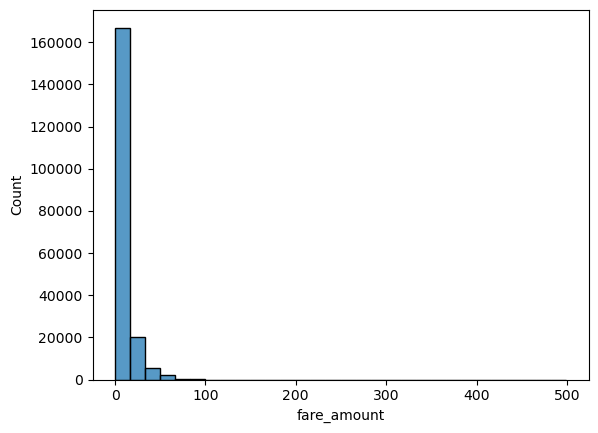

In [36]:
sns.histplot(df['fare_amount'], bins=30)

<Axes: xlabel='passenger_count', ylabel='count'>

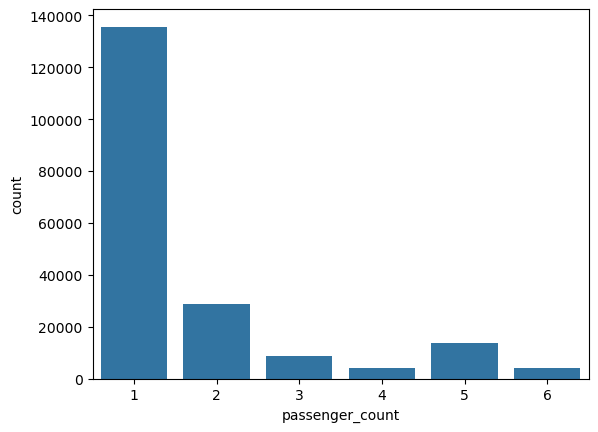

In [37]:
sns.countplot(x='passenger_count',data=df)

<Axes: xlabel='passenger_count', ylabel='fare_amount'>

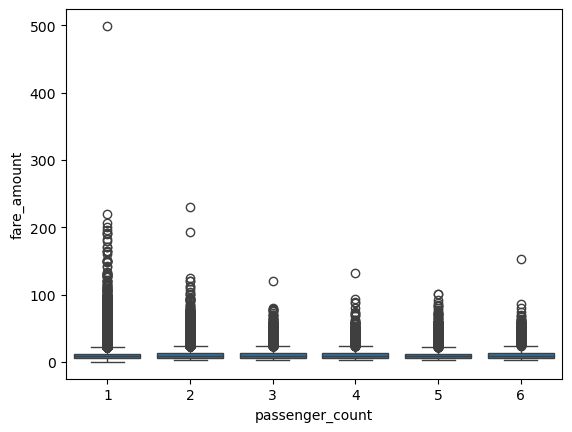

In [38]:
sns.boxplot(x='passenger_count', y='fare_amount', data=df)

<Axes: xlabel='hour', ylabel='fare_amount'>

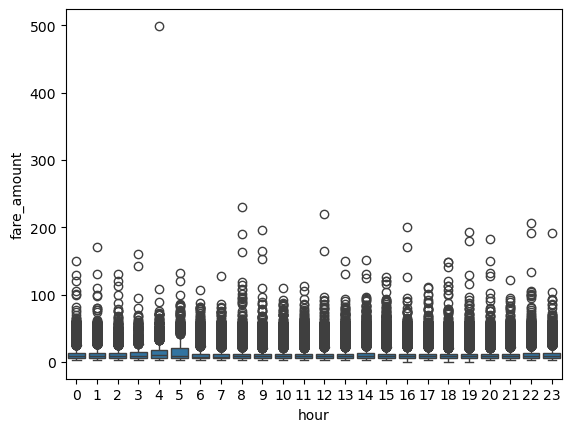

In [39]:
sns.boxplot(x='hour', y='fare_amount',data=df)

In [40]:
corr=df.corr()
corr

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,weekday,month
fare_amount,1.000000,0.005214,-0.002887,0.002363,-0.005316,0.010588,-0.020883,0.000652,0.006389,0.023863
pickup_longitude,0.005214,1.000000,-0.561843,0.632260,-0.600467,0.005662,0.003663,0.010342,0.001328,-0.007085
pickup_latitude,-0.002887,-0.561843,1.000000,-0.564498,0.363954,-0.006277,-0.004889,-0.011578,-0.002976,0.005271
dropoff_longitude,0.002363,0.632260,-0.564498,1.000000,-0.787728,0.003720,0.004772,0.008778,-0.000149,-0.005275
dropoff_latitude,-0.005316,-0.600467,0.363954,-0.787728,1.000000,-0.005555,-0.003561,-0.014619,-0.003757,0.006199
passenger_count,0.010588,0.005662,-0.006277,0.003720,-0.005555,1.000000,0.014699,0.002745,0.036018,0.008701
hour,-0.020883,0.003663,-0.004889,0.004772,-0.003561,0.014699,1.000000,0.005163,-0.086233,-0.004268
day,0.000652,0.010342,-0.011578,0.008778,-0.014619,0.002745,0.005163,1.000000,0.005544,-0.017359
weekday,0.006389,0.001328,-0.002976,-0.000149,-0.003757,0.036018,-0.086233,0.005544,1.000000,-0.009453
month,0.023863,-0.007085,0.005271,-0.005275,0.006199,0.008701,-0.004268,-0.017359,-0.009453,1.000000


df.corr()['fare_amount'].sort_values(ascending=False)

In [42]:
df.corr()['fare_amount'].sort_values(ascending=False)



fare_amount          1.000000
month                0.023863
passenger_count      0.010588
weekday              0.006389
pickup_longitude     0.005214
dropoff_longitude    0.002363
day                  0.000652
pickup_latitude     -0.002887
dropoff_latitude    -0.005316
hour                -0.020883
Name: fare_amount, dtype: float64

In [43]:
import matplotlib.pyplot as plt

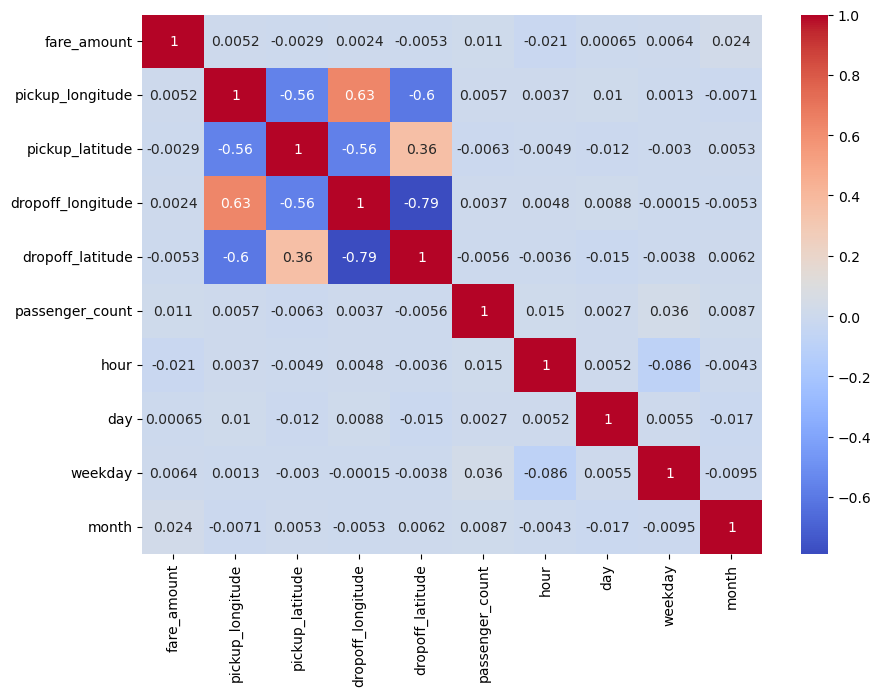

In [44]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(),annot=True, cmap='coolwarm')
plt.show()

### FEATURE ENGINEERING

In [46]:
df['distance']= abs(df['pickup_latitude']- df['dropoff_latitude'])+\
abs(df['pickup_longitude']- df['dropoff_longitude'])              # created a new feature= distance

In [47]:
df.head()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,weekday,month,distance
0,7.5,-73.999817,40.738354,-73.999512,40.723217,1,19,7,3,5,0.015442
1,7.7,-73.994355,40.728225,-73.994710,40.750325,1,20,17,4,7,0.022455
2,12.9,-74.005043,40.740770,-73.962565,40.772647,1,21,24,0,8,0.074355
3,5.3,-73.976124,40.790844,-73.965316,40.803349,3,8,26,4,6,0.023313
4,16.0,-73.925023,40.744085,-73.973082,40.761247,5,17,28,3,8,0.065221


In [48]:
df.corr()['distance'].sort_values(ascending=False)

distance             1.000000
pickup_latitude      0.778085
fare_amount          0.005135
weekday              0.002028
month                0.001285
day                 -0.000809
passenger_count     -0.000935
hour                -0.003719
dropoff_latitude    -0.060884
dropoff_longitude   -0.309768
pickup_longitude    -0.502183
Name: distance, dtype: float64

In [49]:
df['distance'].corr(df['fare_amount'])

0.0051346577248630254

In [50]:
# removing pickup_longitude	pickup_latitude	dropoff_longitude	dropoff_latitude	 bcoz we created distance
df.drop(['pickup_longitude','pickup_latitude','dropoff_longitude','dropoff_latitude'], axis=1, inplace=True)

In [51]:
df.head(1)

,fare_amount,passenger_count,hour,day,weekday,month,distance
0,7.5,1,19,7,3,5,0.015442


In [52]:
df[df['distance']>100]

,fare_amount,passenger_count,hour,day,weekday,month,distance
4949,4.9,1,0,28,5,4,674.018862
32549,15.7,2,10,16,5,6,663.917903
48506,33.7,1,23,5,5,11,661.224375
56617,8.1,1,7,11,6,3,363.691824
61793,8.5,1,5,13,2,6,360.343275
70889,4.5,1,16,2,1,6,114.768053
75851,15.7,1,0,5,5,11,2787.741744
91422,16.1,1,13,18,2,5,3270.155787
103745,12.9,1,19,14,4,10,662.275763
129303,10.1,1,13,11,4,5,113.668142


In [53]:



df=df[df['distance']<100]

In [54]:

df[df['distance']>=100]

,fare_amount,passenger_count,hour,day,weekday,month,distance


### MODEL SELECTION AND TRAINING (LR)

In [56]:
x=df.drop('fare_amount',axis=1) #features
y=df['fare_amount']  #target

In [57]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(
        x,y,test_size=0.2, random_state=42
    
)

In [58]:
from sklearn.linear_model import LinearRegression

In [59]:
model_1=LinearRegression()

In [60]:
model_1.fit(x_train,y_train)

LinearRegression()

In [95]:
Y_pred_lr=model_1.predict(x_test)

### Linear regression model evaluation

In [63]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [64]:
print("RMSE:", mean_squared_error(y_test,Y_pred_lr))

RMSE: 94.50629301729973


In [65]:
print("MAE:",mean_absolute_error(y_test,Y_pred_lr))

MAE: 6.011382935901131


In [66]:
print("R2_score:",r2_score(y_test,Y_pred_lr))

R2_score: 0.0038167977698440048


### RANDOMFOREST REGRESSOR

In [68]:
from sklearn.ensemble import RandomForestRegressor

In [69]:
rf_model_2= RandomForestRegressor()

In [70]:
rf_model_2.fit(x_train,y_train)

RandomForestRegressor()

In [71]:
Y_pred_rf=rf_model_2.predict(x_test)

### RANDOM FORESTREGRESSOR MODEL EVALUATION

In [73]:
from sklearn.metrics import mean_squared_error,mean_absolute_error, r2_score

In [74]:
print("RMSE:", mean_squared_error(y_test,Y_pred_rf))

RMSE: 23.661924754096667


In [75]:
print("MAE:",mean_absolute_error(y_test,Y_pred_rf))

MAE: 2.600609456701811


In [76]:
print("R2_score:",r2_score(y_test,Y_pred_rf))

R2_score: 0.7505815621384055


### XGboost model

In [78]:
!pip install xgboost

In [79]:
from xgboost import XGBRegressor

In [80]:
xg_model_2=XGBRegressor()

In [81]:
xg_model_2.fit(x_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [82]:
Y_pred_xg=xg_model_2.predict(x_test)

### xgboost model evaluation

In [84]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [85]:
print("RMSE:",mean_squared_error(y_test,Y_pred_xg))

RMSE: 24.817919884899855


In [86]:
print("MAE:", mean_absolute_error(y_test,Y_pred_xg))

MAE: 2.504635738701035


In [87]:
print("R2_score:",r2_score(y_test,Y_pred_xg))

R2_score: 0.7383963108244513


In [89]:
import matplotlib.pyplot as plt

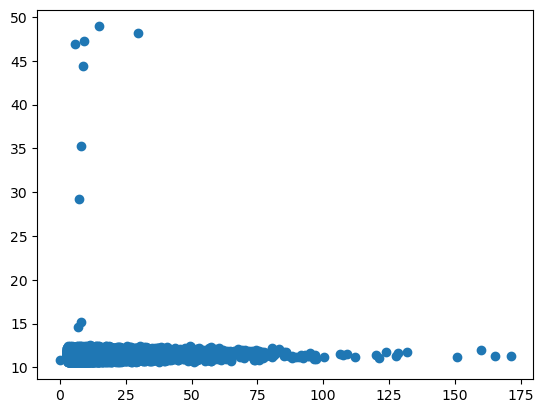

In [99]:
plt.scatter(y_test, Y_pred_lr)

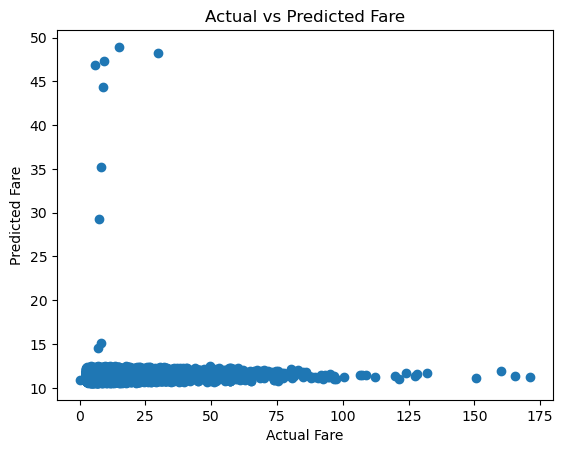

In [101]:
import matplotlib.pyplot as plt

plt.scatter(y_test, Y_pred_lr)
plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Actual vs Predicted Fare")
plt.show()